In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.csv")

In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

In [5]:
# Clean up data: Remove Infs and NaNs
df = df.replace([np.inf, -np.inf], np.nan).dropna()

In [6]:
X = df.drop(columns=['Label'])
y = df['Label']

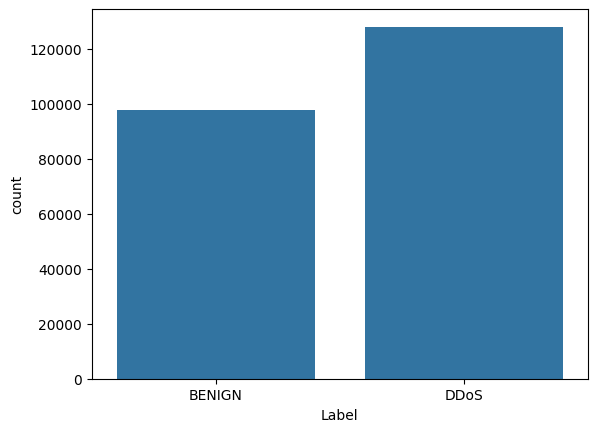

In [13]:
import seaborn as sns

sns.countplot(x = y);

In [7]:
# Binary classification: Benign vs Malicious
y_binary = y.apply(lambda x: 0 if x == 'BENIGN' else 1)

In [9]:
# 3. Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.25, random_state=0)

In [10]:
# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# build the model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
y_pred = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     24287
   Malicious       1.00      1.00      1.00     32141

    accuracy                           1.00     56428
   macro avg       1.00      1.00      1.00     56428
weighted avg       1.00      1.00      1.00     56428



### llm

In [14]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
import json
import numpy as np

/home/aditya/GEN_AI_GOOGLE_NEW/venv_google_langchain_new/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
# 1. Initialize our local, free LLM (Google Gemma)
llm = Ollama(model="qwen-coder-fast:latest")

/tmp/ipykernel_125220/946277290.py:2: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="qwen-coder-fast:latest")


In [16]:
# 2. Create the SOC Analyst Prompt
template = """
You are an expert Cybersecurity SOC Analyst. 
A Machine Learning model has flagged the following network traffic flow as MALICIOUS.

Here is the raw tabular data for the network flow in JSON format:
{network_data}

Based on this data, please provide:
1. Threat Analysis: What kind of attack does this look like based on the features (e.g., high packet rate, specific port)?
2. Explanation: Explain why these specific metrics triggered the anomaly in simple terms.
3. Mitigation Action: What immediate steps should the network administrator take?

Keep your answer professional, concise, and structured.
"""

In [17]:
prompt = PromptTemplate(
    input_variables=["network_data"],
    template=template,
)

In [18]:
# 3. Simulate an Anomaly (Grabbing a malicious row from our test set)
# Let's find an index where our ML model predicted a '1' (Malicious)
malicious_indices = np.where(y_pred == 1)[0]
if len(malicious_indices) > 0:
    sample_idx = malicious_indices[0]
    
    # Extract the original unscaled row to give the LLM real context
    anomalous_row = X_test.iloc[sample_idx].to_dict()
    
    # Convert tabular data to JSON string for the LLM
    network_data_json = json.dumps(anomalous_row, indent=2)
    
    print("\n--- Sending Anomaly to Qwen for Analysis ---")
    
    # Create the chain and invoke it
    chain = prompt | llm
    response = chain.invoke({"network_data": network_data_json})
    
    print("\n[SOC Analyst Incident Report]")
    print(response)
else:
    print("No malicious traffic detected in this sample.")


--- Sending Anomaly to Qwen for Analysis ---

[SOC Analyst Incident Report]
### Threat Analysis

This network flow looks like a potential SYN Flood attack based on several key features:
- **High Packet Rate**: The `Flow Packets/s` is very high at 2.412182971 packets per second, indicating that the flow is generating a large number of packets in a short period.
- **Specific Port**: The destination port is 80, which is commonly used for HTTP traffic. SYN Flood attacks often target this port to overwhelm the server with SYN requests that never complete (SYN+ACK).
- **Short Packet Length and Lack of Backward Traffic**: The `Total Fwd Packets` is 4 while `Total Backward Packets` is 0, indicating that there are no responses or acknowledgments from the destination server. This is typical in a SYN Flood attack.
- **High IAT (Inter-Arrival Time)**: The mean and maximum IAT values are very high (552749.6667 and 1657764 respectively), which suggests that there are large gaps between the packets,